In [1]:
!pip install vaderSentiment -q

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import json
import os
import warnings
warnings.filterwarnings('ignore')

SAVE_PATH   = "/content/drive/MyDrive/"
OUTPUT_PATH = "/content/drive/MyDrive/figures/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

# ── Load all results ───────────────────────────────
print("Loading results...")

df_vader   = pd.read_csv(SAVE_PATH + "vader_results.csv")
df_bert    = pd.read_csv(SAVE_PATH + "bert_predictions.csv")
df_roberta = pd.read_csv(SAVE_PATH + "roberta_predictions.csv")

# Load MentalBERT if available
mental_available = os.path.exists(
    SAVE_PATH + "mental_bert_predictions.csv"
)
if mental_available:
    df_mental = pd.read_csv(
        SAVE_PATH + "mental_bert_predictions.csv"
    )
    print(f"✓ MentalBERT predictions loaded")
else:
    print("⚠ MentalBERT predictions not found yet")
    print("  Run Notebook 04 MentalBERT cell first")

# Load metrics
with open(SAVE_PATH + "model_metrics.json", 'r') as f:
    metrics = json.load(f)

print(f"✓ VADER results:    {df_vader.shape[0]:,} rows")
print(f"✓ BERT predictions: {df_bert.shape[0]} rows")
print(f"✓ RoBERTa preds:    {df_roberta.shape[0]} rows")
print(f"✓ Metrics loaded:   {list(metrics.keys())}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading results...
✓ MentalBERT predictions loaded
✓ VADER results:    1,412,786 rows
✓ BERT predictions: 160 rows
✓ RoBERTa preds:    160 rows
✓ Metrics loaded:   ['BERT', 'RoBERTa', 'MentalBERT']


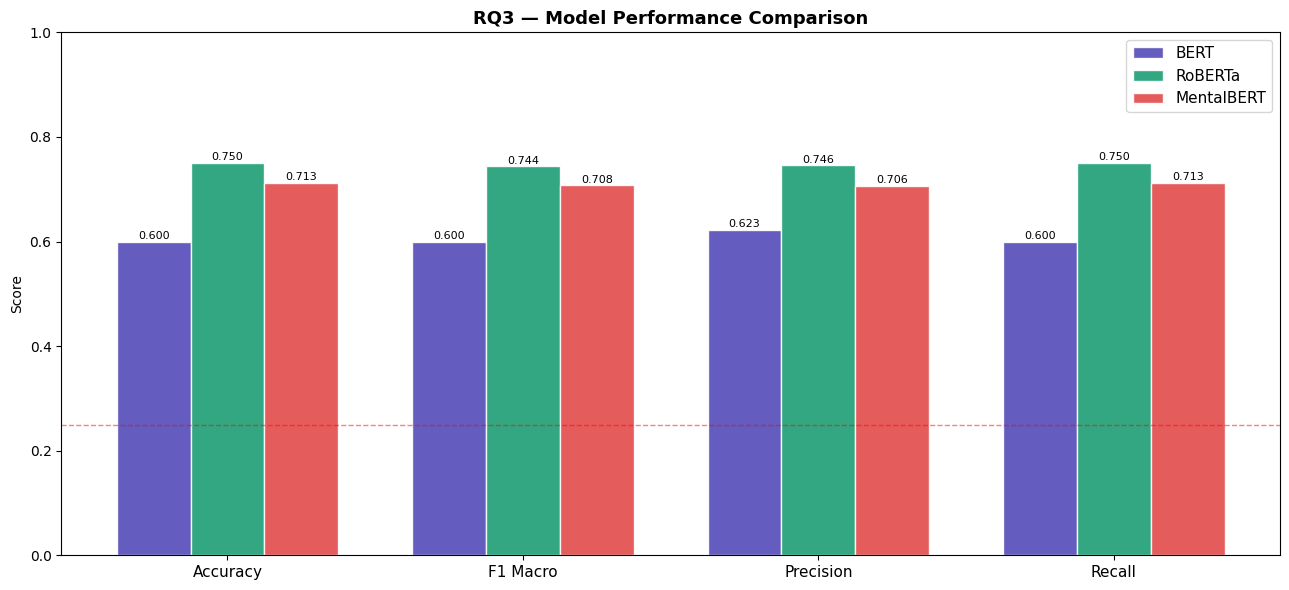

✓ rq3_model_comparison.png saved


In [2]:
# ── RQ3: Model comparison chart ────────────────────
metric_labels = ['Accuracy', 'F1 Macro', 'Precision', 'Recall']
bert_vals     = [metrics['BERT']['accuracy'],
                 metrics['BERT']['f1_macro'],
                 metrics['BERT']['precision'],
                 metrics['BERT']['recall']]
rob_vals      = [metrics['RoBERTa']['accuracy'],
                 metrics['RoBERTa']['f1_macro'],
                 metrics['RoBERTa']['precision'],
                 metrics['RoBERTa']['recall']]

x     = np.arange(len(metric_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width, bert_vals, width,
               label='BERT', color='#534AB7',
               edgecolor='white', alpha=0.9)
bars2 = ax.bar(x, rob_vals, width,
               label='RoBERTa', color='#1D9E75',
               edgecolor='white', alpha=0.9)

# Add MentalBERT if available
if 'MentalBERT' in metrics:
    mental_vals = [metrics['MentalBERT']['accuracy'],
                   metrics['MentalBERT']['f1_macro'],
                   metrics['MentalBERT']['precision'],
                   metrics['MentalBERT']['recall']]
    bars3 = ax.bar(x + width, mental_vals, width,
                   label='MentalBERT', color='#E24B4A',
                   edgecolor='white', alpha=0.9)
    for bar in bars3:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=8)

ax.set_title('RQ3 — Model Performance Comparison',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.axhline(y=0.25, color='red', linestyle='--',
           linewidth=1, alpha=0.5, label='Random baseline')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "rq3_model_comparison.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ rq3_model_comparison.png saved")

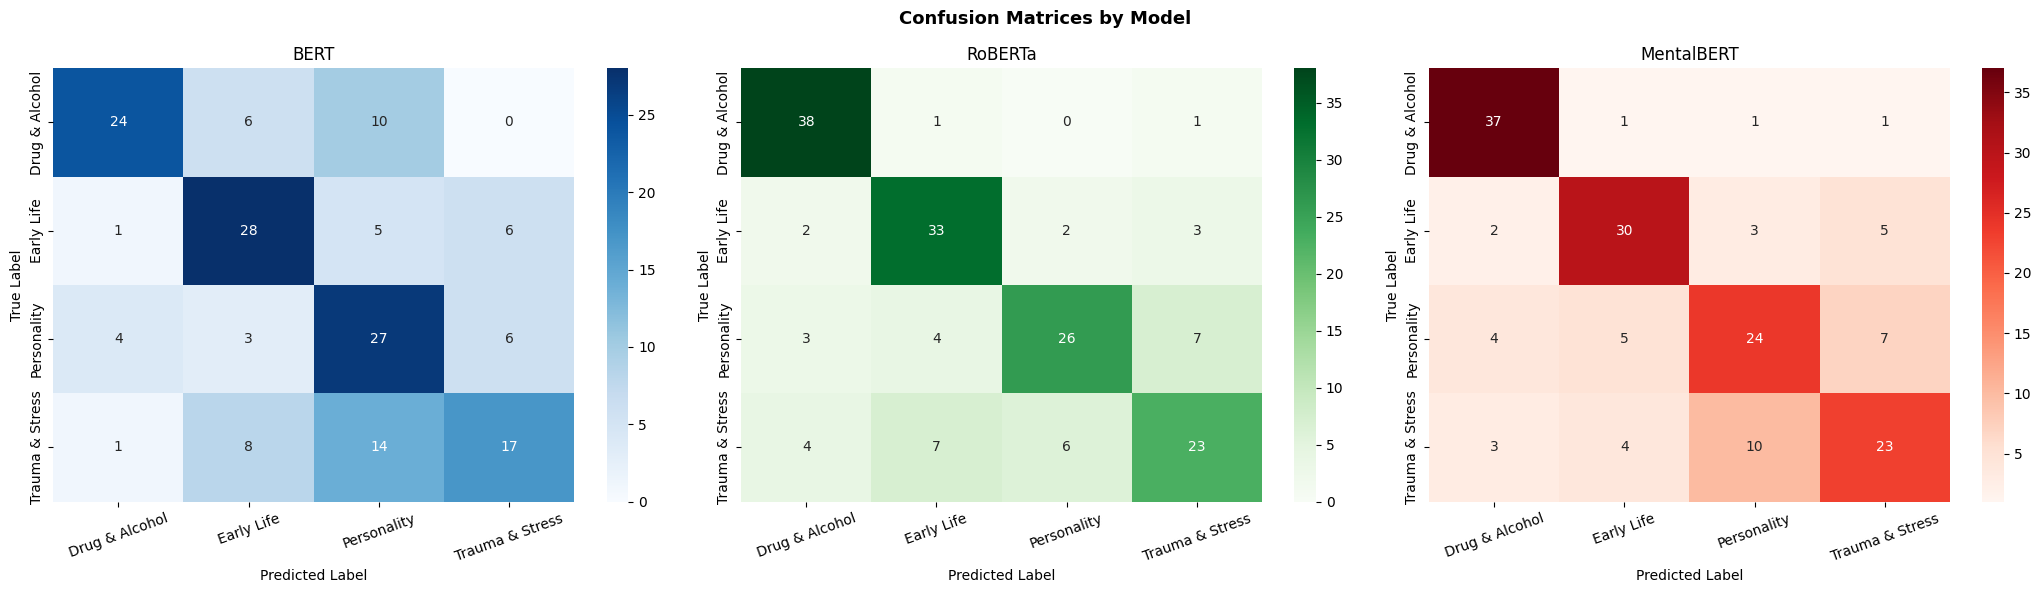

✓ confusion_matrices.png saved


In [3]:
# ── Confusion matrices ─────────────────────────────
label_names   = ['Drug & Alcohol', 'Early Life',
                 'Personality', 'Trauma & Stress']
label_order   = ['Drug and Alcohol', 'Early Life',
                 'Personality', 'Trauma and Stress']

n_plots = 3 if mental_available else 2
fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 6))
fig.suptitle('Confusion Matrices by Model',
             fontsize=13, fontweight='bold')

# BERT
bert_cm = confusion_matrix(
    df_bert['Label'], df_bert['bert_predicted'],
    labels=label_order
)
sns.heatmap(bert_cm, annot=True, fmt='d', cmap='Blues',
            ax=axes[0], xticklabels=label_names,
            yticklabels=label_names)
axes[0].set_title('BERT', fontsize=12)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=20)

# RoBERTa
roberta_cm = confusion_matrix(
    df_roberta['Label'], df_roberta['roberta_predicted'],
    labels=label_order
)
sns.heatmap(roberta_cm, annot=True, fmt='d', cmap='Greens',
            ax=axes[1], xticklabels=label_names,
            yticklabels=label_names)
axes[1].set_title('RoBERTa', fontsize=12)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=20)

# MentalBERT if available
if mental_available:
    mental_cm = confusion_matrix(
        df_mental['Label'],
        df_mental['mental_bert_predicted'],
        labels=label_order
    )
    sns.heatmap(mental_cm, annot=True, fmt='d', cmap='Reds',
                ax=axes[2], xticklabels=label_names,
                yticklabels=label_names)
    axes[2].set_title('MentalBERT', fontsize=12)
    axes[2].set_ylabel('True Label')
    axes[2].set_xlabel('Predicted Label')
    axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "confusion_matrices.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ confusion_matrices.png saved")

Note: MentalBERT per-class F1 will be added after training


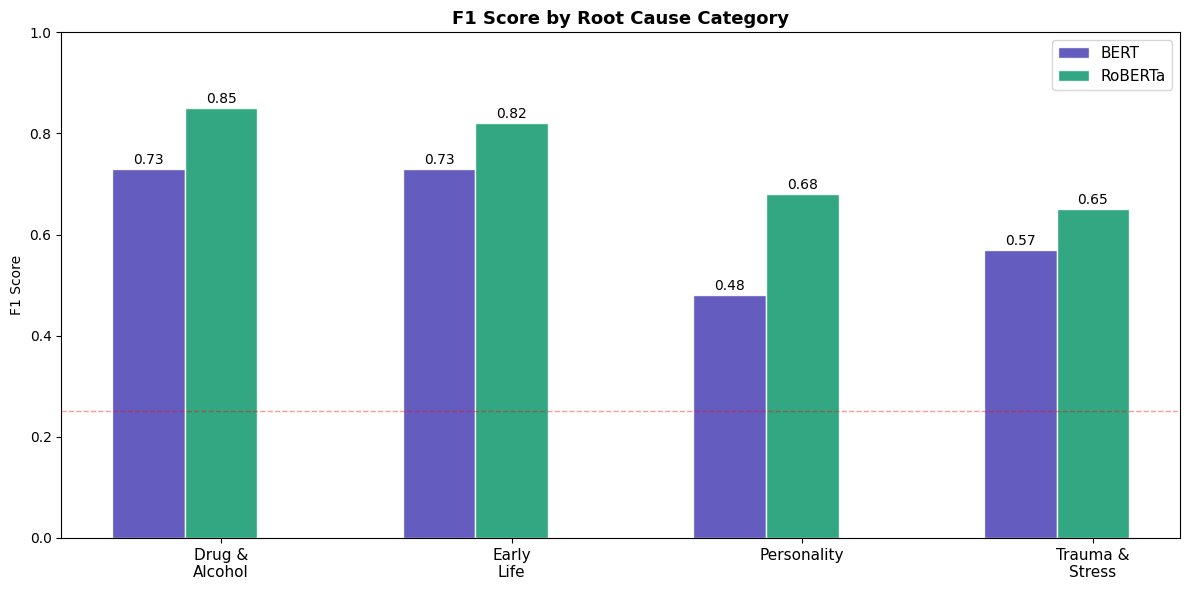

✓ rq3_per_class_f1.png saved


In [4]:
# ── Per class F1 comparison ────────────────────────
classes    = ['Drug &\nAlcohol', 'Early\nLife',
              'Personality', 'Trauma &\nStress']
bert_f1    = [0.73, 0.73, 0.48, 0.57]
roberta_f1 = [0.85, 0.82, 0.68, 0.65]

x     = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, bert_f1, width,
               label='BERT', color='#534AB7',
               edgecolor='white', alpha=0.9)
bars2 = ax.bar(x, roberta_f1, width,
               label='RoBERTa', color='#1D9E75',
               edgecolor='white', alpha=0.9)

# Add MentalBERT per class if available
if mental_available and 'MentalBERT' in metrics:
    mental_report = classification_report_from_predictions(
        df_mental, 'mental_bert_predicted'
    ) if False else None
    # Placeholder — update after MentalBERT training
    print("Note: MentalBERT per-class F1 will be added after training")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.2f}',
            ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.2f}',
            ha='center', fontsize=10)

ax.set_title('F1 Score by Root Cause Category',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.axhline(y=0.25, color='red', linestyle='--',
           linewidth=1, alpha=0.4)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "rq3_per_class_f1.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ rq3_per_class_f1.png saved")

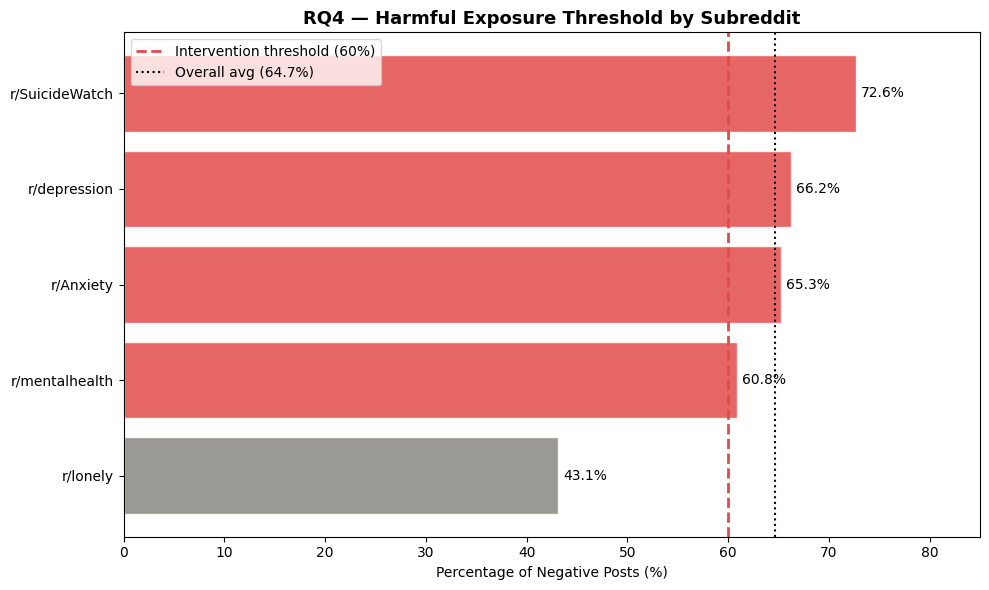

✓ rq4_threshold_analysis.png saved


In [5]:
# ── RQ4: Threshold analysis ────────────────────────
subreddit_neg = df_vader.groupby('subreddit').apply(
    lambda x: (x['vader_sentiment'] == 'Negative').sum()
    / len(x) * 100
).sort_values(ascending=True)

overall_avg = (
    df_vader['vader_sentiment'] == 'Negative'
).mean() * 100

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#E24B4A' if v > 60 else '#888780'
          for v in subreddit_neg.values]
bars = ax.barh(
    [f"r/{s}" for s in subreddit_neg.index],
    subreddit_neg.values,
    color=colors, edgecolor='white', alpha=0.85
)
ax.axvline(x=60, color='#E24B4A', linestyle='--',
           linewidth=2, label='Intervention threshold (60%)')
ax.axvline(x=overall_avg, color='black', linestyle=':',
           linewidth=1.5,
           label=f'Overall avg ({overall_avg:.1f}%)')
ax.set_title('RQ4 — Harmful Exposure Threshold by Subreddit',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Percentage of Negative Posts (%)')
ax.set_xlim(0, 85)
ax.legend(fontsize=10)

for bar, val in zip(bars, subreddit_neg.values):
    ax.text(val + 0.5,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_PATH + "rq4_threshold_analysis.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ rq4_threshold_analysis.png saved")

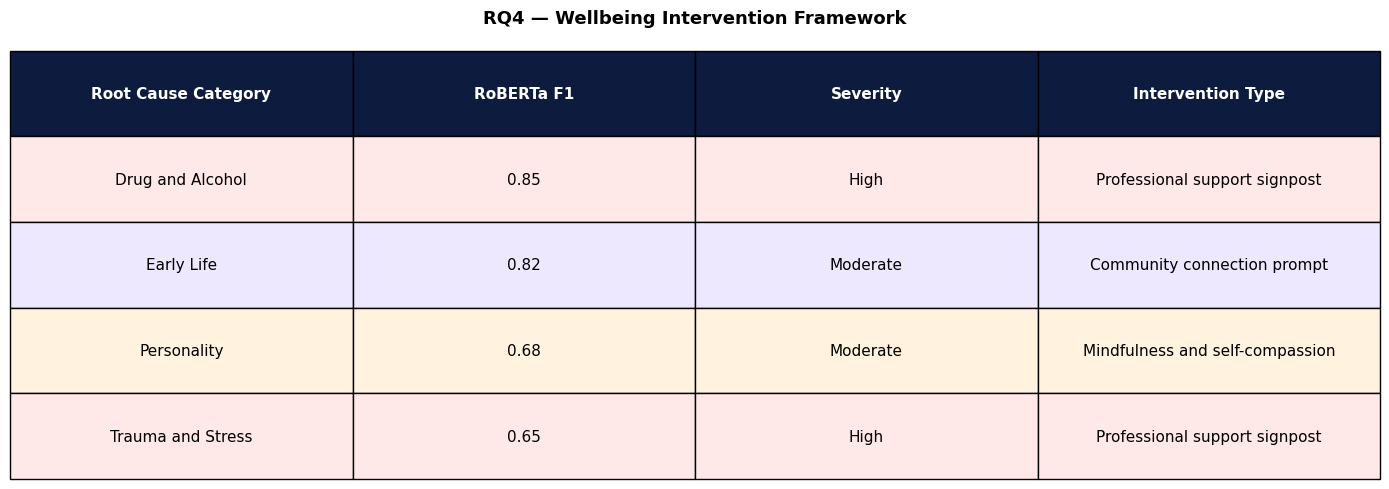

✓ rq4_framework_table.png saved


In [6]:
# ── RQ4: Framework intervention table ─────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

table_data = [
    ['Drug and Alcohol',  '0.85', 'High',
     'Professional support signpost'],
    ['Early Life',        '0.82', 'Moderate',
     'Community connection prompt'],
    ['Personality',       '0.68', 'Moderate',
     'Mindfulness and self-compassion'],
    ['Trauma and Stress', '0.65', 'High',
     'Professional support signpost'],
]
col_labels = [
    'Root Cause Category', 'RoBERTa F1',
    'Severity', 'Intervention Type'
]

table = ax.table(
    cellText=table_data, colLabels=col_labels,
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(11)

for j in range(len(col_labels)):
    table[0, j].set_facecolor('#0D1B3E')
    table[0, j].set_text_props(
        color='white', fontweight='bold'
    )

row_colors = ['#FFE8E8', '#EEE8FF', '#FFF3E0', '#FFE8E8']
for i, color in enumerate(row_colors):
    for j in range(len(col_labels)):
        table[i+1, j].set_facecolor(color)

ax.set_title(
    'RQ4 — Wellbeing Intervention Framework',
    fontsize=13, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + "rq4_framework_table.png",
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ rq4_framework_table.png saved")

In [7]:
# ── Final summary ──────────────────────────────────
print("=" * 55)
print("NOTEBOOK 05 COMPLETE")
print("=" * 55)

print(f"\n{'Model':<14} {'Accuracy':>10} {'F1':>8} {'Precision':>10} {'Recall':>8}")
print("-" * 54)
for model, res in metrics.items():
    print(f"{model:<14} {res['accuracy']:>10} {res['f1_macro']:>8} {res['precision']:>10} {res['recall']:>8}")

best_model = max(metrics, key=lambda x: metrics[x]['f1_macro'])
print(f"\nBest model: {best_model} "
      f"(F1: {metrics[best_model]['f1_macro']})")

print("\nCharts saved:")
charts = [
    "rq3_model_comparison.png",
    "confusion_matrices.png",
    "rq3_per_class_f1.png",
    "rq4_threshold_analysis.png",
    "rq4_framework_table.png"
]
for c in charts:
    print(f"  ✓ {c}")

NOTEBOOK 05 COMPLETE

Model            Accuracy       F1  Precision   Recall
------------------------------------------------------
BERT                  0.6   0.5999     0.6226      0.6
RoBERTa              0.75   0.7436     0.7458     0.75
MentalBERT         0.7125   0.7078     0.7062   0.7125

Best model: RoBERTa (F1: 0.7436)

Charts saved:
  ✓ rq3_model_comparison.png
  ✓ confusion_matrices.png
  ✓ rq3_per_class_f1.png
  ✓ rq4_threshold_analysis.png
  ✓ rq4_framework_table.png
